In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
import seaborn as sns
from mlxtend.plotting import plot_decision_regions
import os

os.environ["TF_DETERMINISTIC_OPS"] = "1"
os.environ["PYTHONHASHSEED"] = "0"

# 2. Set non-TensorFlow seeds
import random
import numpy as np

random.seed(42)
np.random.seed(42)

# 3. Import TensorFlow and set its seed last
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Flatten

tf.random.set_seed(42)
from tensorflow.keras.layers import Dropout
from tensorflow.keras.optimizers import Adam

### DataSet

In [2]:
X, y = make_moons(100, noise=0.25,random_state=2) 

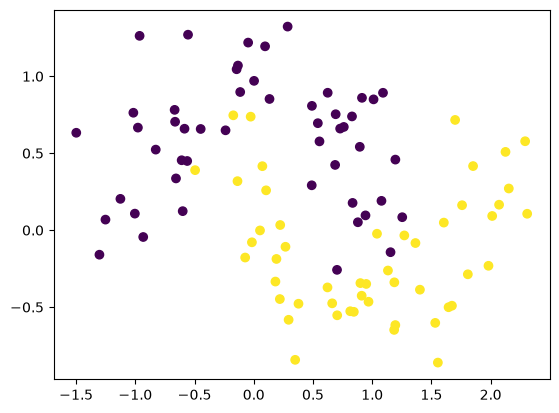

In [3]:
import matplotlib.pyplot as plt
plt.scatter(X[:,0], X[:,1], c=y)
plt.show()

### Without Regularzation

In [4]:
model=Sequential([
    Dense(units=128 , activation='relu'),
    Dense(units=64 , activation='relu' ), 
    Dense(units=32 , activation='relu' ), 
    Dense(units=1 , activation="sigmoid")
])

In [5]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ ?                           │     0 (unbuilt) │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [6]:
model.get_weights()

[]

In [7]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor="val_loss",
    verbose=1,
    min_delta=0.00001,
    patience=4,
    restore_best_weights=True
)

In [8]:
adam = Adam(learning_rate=0.01)
model.compile(loss='binary_crossentropy', optimizer=adam, metrics=['accuracy'])

history1 = model.fit(X, y, epochs=2000, validation_split = 0.2,verbose=1 , callbacks=[early_stop])

Epoch 1/2000
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 147ms/step - accuracy: 0.6875 - loss: 0.6260 - val_accuracy: 0.9000 - val_loss: 0.4510
Epoch 2/2000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.8125 - loss: 0.4498 - val_accuracy: 0.9000 - val_loss: 0.2306
Epoch 3/2000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.8250 - loss: 0.3919 - val_accuracy: 0.9000 - val_loss: 0.1739
Epoch 4/2000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.8375 - loss: 0.3966 - val_accuracy: 0.9000 - val_loss: 0.1909
Epoch 5/2000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.8500 - loss: 0.3589 - val_accuracy: 0.9000 - val_loss: 0.2049
Epoch 6/2000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.8500 - loss: 0.3400 - val_accuracy: 0.9000 - val_loss: 0.2164
Epoch 7/2000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.8500 - loss: 0.3202 - val_accuracy: 0.9000 - val_loss: 0.1909
Epoch 7: early stopping
Restoring model weights from the end of the best epoch: 3.


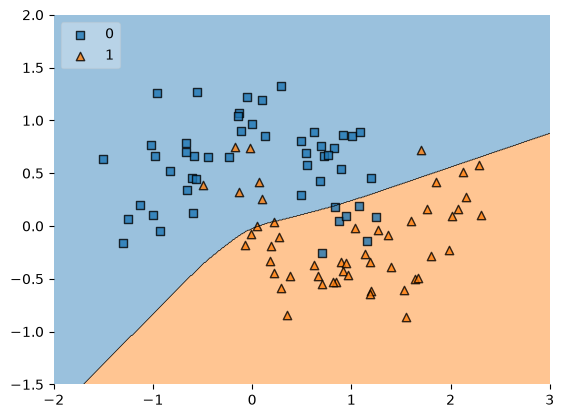

In [9]:
class KerasClassifierWrapper:
    def __init__(self, model):
        self.model = model
    def predict(self, X):
        preds = self.model.predict(X, verbose=0)
        return (preds > 0.5).astype(int).ravel()  # flatten to 1D int labels

wrapped_model = KerasClassifierWrapper(model)
plot_decision_regions(X, y.astype(int), clf=wrapped_model, legend=2)
plt.xlim(-2, 3)
plt.ylim(-1.5, 2)
plt.show()

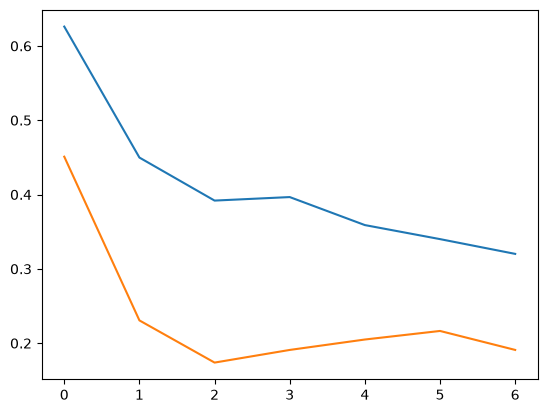

In [10]:
plt.plot(history1.history['loss'])
plt.plot(history1.history['val_loss'])

### With Regularization

In [11]:
import tensorflow
model2=Sequential([
    Dense(units=128 , activation='relu' , kernel_regularizer=tensorflow.keras.regularizers.l2(0.01)),
    Dense(units=64 , activation='relu' ,kernel_regularizer=tensorflow.keras.regularizers.l2(0.01)), 
    Dense(units=32 , activation='relu' ,kernel_regularizer=tensorflow.keras.regularizers.l2(0.01)), 
    Dense(units=1 , activation="sigmoid")
])

In [12]:
adam = Adam(learning_rate=0.01)
model2.compile(loss='binary_crossentropy', optimizer=adam, metrics=['accuracy'])

history2 = history1 = model2.fit(X, y, epochs=2000, validation_split = 0.2,verbose=1 , callbacks=[early_stop])

Epoch 1/2000
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 154ms/step - accuracy: 0.5250 - loss: 1.8399 - val_accuracy: 0.8000 - val_loss: 1.4602
Epoch 2/2000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.7375 - loss: 1.3288 - val_accuracy: 0.9000 - val_loss: 1.0454
Epoch 3/2000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.8250 - loss: 0.9609 - val_accuracy: 0.9000 - val_loss: 0.7184
Epoch 4/2000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.8250 - loss: 0.7348 - val_accuracy: 0.9000 - val_loss: 0.5099
Epoch 5/2000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.8250 - loss: 0.6296 - val_accuracy: 0.9000 - val_loss: 0.4153
Epoch 6/2000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.8250 - loss: 0.5744 - val_accuracy: 0.9000 - val_loss: 0.3900
Epoch 7/2000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.8500 - loss: 0.5360 - val_accuracy: 0.9000 - val_loss: 0.3985
Epoch 8/2000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.8500 - loss: 0.5111 - val_accuracy: 0.9000 - 

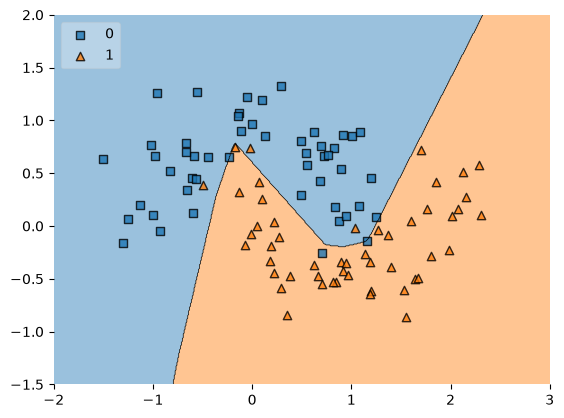

In [13]:
class KerasClassifierWrapper:
    def __init__(self, model):
        self.model = model
    def predict(self, X):
        preds = self.model.predict(X, verbose=0)
        return (preds > 0.5).astype(int).ravel()  # flatten to 1D int labels

wrapped_model = KerasClassifierWrapper(model2)
plot_decision_regions(X, y.astype(int), clf=wrapped_model, legend=2)
plt.xlim(-2, 3)
plt.ylim(-1.5, 2)
plt.show()

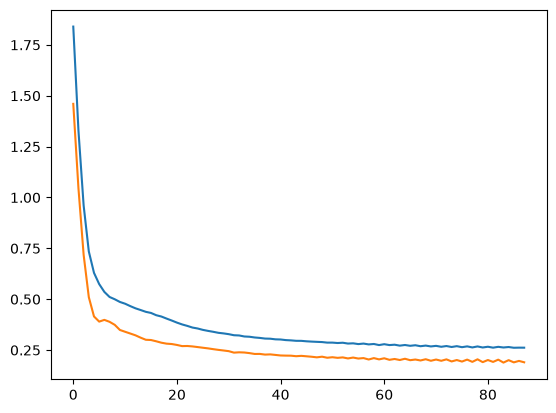

In [14]:
plt.plot(history2.history['loss'])
plt.plot(history2.history['val_loss'])